
# Sistema de Recomendação com PySpark: Abordagem Comparativa

## 1. Introdução

Este projeto implementa e compara três estratégias de sistemas de recomendação utilizando PySpark: filtragem colaborativa com Alternating Least Squares (ALS), sistema baseado em conteúdo usando TF-IDF, e uma abordagem híbrida que combina ambos os métodos.

O objetivo é demonstrar o processo analítico completo de desenvolvimento de sistemas de recomendação, desde a análise exploratória até a avaliação quantitativa de performance, fornecendo insights técnicos sobre as vantagens e limitações de cada abordagem.


## 2. Objetivos do Projeto

- **Análise Exploratória**: Caracterizar o dataset de interações usuário-item para identificar padrões e informar decisões de modelagem
- **Filtragem Colaborativa**: Implementar e avaliar modelo ALS para capturar preferências latentes através de interações históricas
- **Sistema Baseado em Conteúdo**: Desenvolver recomendações usando similaridade de atributos (gêneros) via TF-IDF
- **Abordagem Híbrida**: Combinar ambos os métodos para maximizar relevância e diversidade
- **Avaliação Quantitativa**: Comparar sistemas usando métricas padrão da área (Precision@K, Recall@K, MAP@K, NDCG@K)

## 3. Configuração do Ambiente Spark

O primeiro passo é configurar adequadamente a sessão Spark com parâmetros otimizados para processamento de dados de recomendação.


### 3.1. Importando bibliotecas

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as spark_sum
from pyspark.sql.functions import col
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import explode
from pyspark.sql.functions import split, explode, trim, col, lit
from pyspark.sql.functions import avg
from pyspark.sql import Row
import random
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Criação da sessão Spark para leitura de dados
spark = SparkSession.builder \
    .appName("Leitura CSVs") \
    .getOrCreate()


# Carregamento dos datasets com inferência automática de schema
df_ratings = spark.read.csv("/Users/paulohenriquesiqueira/Scripts/recommender_movielens/data/ratings.csv", header=True, inferSchema=True)
df_movies = spark.read.csv("/Users/paulohenriquesiqueira/Scripts/recommender_movielens/data/movies.csv", header=True, inferSchema=True)
df_tags = spark.read.csv("/Users/paulohenriquesiqueira/Scripts/recommender_movielens/data/tags.csv", header=True, inferSchema=True)



Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/07/08 14:12:27 WARN Utils: Your hostname, MacBook-Air-de-Paulo.local, resolves to a loopback address: 127.0.0.1; using 192.168.68.111 instead (on interface en0)
25/07/08 14:12:27 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/08 14:12:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 4. Análise Exploratória dos Dados (EDA)

A análise exploratória é fundamental para compreender a estrutura dos dados e identificar características que impactarão a modelagem, como sparsity, distribuição de ratings e cold start.


### 4.1 Estrutura dos Dados

In [4]:
# Análise da estrutura dos datasets
df_ratings.printSchema()
df_movies.printSchema()
df_tags.printSchema()

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- tag: string (nullable = true)
 |-- timestamp: integer (nullable = true)



In [5]:
# Visualização das primeiras observações para validação da carga
df_ratings.show(5)
df_movies.show(5)
df_tags.show(5)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
+------+-------+------+---------+
only showing top 5 rows
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows
+------+-------+---------------+----------+
|userId|movieId|            tag| timestamp|
+------+-------+---------------+----------+
|     2|  60756|          funny|1445714994|
| 


**Interpretação**: Esta etapa valida a integridade da carga de dados e confirma que os tipos de dados estão corretos para as operações subsequentes.

### 4.2 Análise de Qualidade dos Dados

In [6]:
# Contagem de registros e identificação de valores nulos
print("Ratings:", df_ratings.count())
print("Movies:", df_movies.count())
print("Tags:", df_tags.count())


def count_nulls(df):
    """Função utilitária para contagem de valores nulos por coluna"""
    return df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])

print("Nulls em Ratings:")
count_nulls(df_ratings).show()

print("Nulls em Movies:")
count_nulls(df_movies).show()

print("Nulls em Tags:")
count_nulls(df_tags).show()

Ratings: 100836
Movies: 9742
Tags: 3683
Nulls em Ratings:
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

Nulls em Movies:
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+

Nulls em Tags:
+------+-------+---+---------+
|userId|movieId|tag|timestamp|
+------+-------+---+---------+
|     0|      0|  0|        0|
+------+-------+---+---------+




**Análise Técnica**: A ausência de valores nulos nos datasets principais (ratings e movies) é crucial para a estabilidade dos algoritmos de recomendação, eliminando a necessidade de estratégias de imputação que poderiam introduzir viés.


### 4.3 Distribuição de Ratings


In [7]:
# Análise da distribuição de ratings para compreender preferências dos usuários
df_ratings.groupBy("rating").count().orderBy("rating").show()

+------+-----+
|rating|count|
+------+-----+
|   0.5| 1370|
|   1.0| 2811|
|   1.5| 1791|
|   2.0| 7551|
|   2.5| 5550|
|   3.0|20047|
|   3.5|13136|
|   4.0|26818|
|   4.5| 8551|
|   5.0|13211|
+------+-----+




**Interpretação dos Resultados**: A distribuição de ratings revela padrões comportamentais dos usuários. Ratings mais altos (4.0-5.0) indicam satisfação, enquanto a presença de ratings baixos fornece sinal negativo para filtragem colaborativa.


### 4.4 Análise de Sparsity

In [8]:
# Cálculo de usuários e filmes únicos para análise de densidade da matriz
n_users = df_ratings.select("userId").distinct().count()
n_movies = df_ratings.select("movieId").distinct().count()
print(f"Usuários únicos: {n_users}")
print(f"Filmes únicos avaliados: {n_movies}")

Usuários únicos: 610
Filmes únicos avaliados: 9724


In [9]:
# Identificação de usuários mais ativos (potenciais influenciadores)
df_ratings.groupBy("userId").count().orderBy("count", ascending=False).show(10)

+------+-----+
|userId|count|
+------+-----+
|   414| 2698|
|   599| 2478|
|   474| 2108|
|   448| 1864|
|   274| 1346|
|   610| 1302|
|    68| 1260|
|   380| 1218|
|   606| 1115|
|   288| 1055|
+------+-----+
only showing top 10 rows


In [10]:
# Análise de popularidade dos filmes e identificação do problema de long tail
df_ratings.groupBy("movieId").count().orderBy("count", ascending=False).show(10)

# Quantificação do cold start problem
filmes_uma_avaliacao = df_ratings.groupBy("movieId").count().filter("count = 1").count()
print(f"Filmes com apenas uma avaliação: {filmes_uma_avaliacao}")

+-------+-----+
|movieId|count|
+-------+-----+
|    356|  329|
|    318|  317|
|    296|  307|
|    593|  279|
|   2571|  278|
|    260|  251|
|    480|  238|
|    110|  237|
|    589|  224|
|    527|  220|
+-------+-----+
only showing top 10 rows
Filmes com apenas uma avaliação: 3446



**Implicações para Modelagem**: 

A identificação de que aproximadamente 35% dos filmes possuem apenas uma avaliação caracteriza o problema de "long tail" típico em sistemas de recomendação. Essa sparsity elevada justifica a aplicação de filtros mínimos de interação para melhorar a robustez do modelo ALS.



## 5. Pré-processamento para Filtragem Colaborativa


### 5.1 Estratégia de Filtragem

Para mitigar problemas de sparsity e cold start, aplicamos filtros mínimos baseados em frequência de interações, uma prática padrão que melhora a estabilidade e generalização do modelo colaborativo.


In [11]:
# Filtro 1: Filmes com pelo menos 5 avaliações
movies_with_5_ratings = (
    df_ratings.groupBy("movieId")
    .count()
    .filter(col("count") >= 5)
    .select("movieId")
)

df_ratings_filt = df_ratings.join(movies_with_5_ratings, on="movieId", how="inner")
print("Filmes após filtro:", df_ratings_filt.select("movieId").distinct().count())


Filmes após filtro: 3650



**Justificativa Técnica**: O filtro de 5 avaliações mínimas remove filmes com informação insuficiente para estimativas confiáveis de fatores latentes no ALS, reduzindo overfitting.


In [12]:
# Filtro 2: Usuários com pelo menos 5 avaliações (aplicado sequencialmente)
users_with_5_ratings = (
    df_ratings_filt.groupBy("userId")
    .count()
    .filter(col("count") >= 5)
    .select("userId")
)

df_ratings_filt = df_ratings_filt.join(users_with_5_ratings, on="userId", how="inner")
print("Usuários após filtro:", df_ratings_filt.select("userId").distinct().count())
print("Avaliações após filtro:", df_ratings_filt.count())

Usuários após filtro: 610
Avaliações após filtro: 90274



**Resultado da Filtragem**: A redução controlada do dataset (mantendo usuários ativos e filmes com volume mínimo de interações) melhora a qualidade das recomendações sem perda significativa de informação.


### 5.2 Divisão Treino/Teste

**Consideração Metodológica**: A divisão 80/20 com seed fixo garante reprodutibilidade e volume adequado para treinamento e validação estatística dos resultados.


In [13]:
# Separação estratificada para avaliação robusta
train_df, test_df = df_ratings_filt.randomSplit([0.8, 0.2], seed=42)

print("Treino:", train_df.count())
print("Teste:", test_df.count())

Treino: 72120
Teste: 18154




## 6. Modelagem: Filtragem Colaborativa (ALS)

### 6.1 Configuração e Treinamento do Modelo

In [14]:
# Configuração do modelo ALS com hiperparâmetros balanceados
als = ALS(
    userCol="userId",
    itemCol="movieId", 
    ratingCol="rating",
    nonnegative=True,        # Garante fatores não-negativos (interpretabilidade)
    implicitPrefs=False,     # Ratings explícitos (não binários)
    coldStartStrategy="drop", # Remove previsões para usuários/itens não vistos
    maxIter=10,              # Iterações para convergência
    regParam=0.1,            # Regularização L2 para evitar overfitting
    rank=10,                 # Dimensionalidade dos fatores latentes
    seed=42                  # Reprodutibilidade
)

# Treinamento do modelo
model = als.fit(train_df)

# Avaliação no conjunto de teste
predictions = model.transform(test_df)

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating", 
    predictionCol="prediction"
)
rmse = evaluator.evaluate(predictions)
print(f"RMSE no teste: {rmse:.4f}")

25/07/08 14:12:38 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


RMSE no teste: 0.8540


**Interpretação do RMSE**: Um RMSE inferior a 1.0 em uma escala de ratings de 0.5-5.0 indica excelente capacidade preditiva, com erro médio inferior a uma estrela, demonstrando que o modelo capturou efetivamente os padrões de preferência dos usuários.


### 6.2 Geração de Recomendações


In [15]:
# Geração de recomendações top-5 para usuários selecionados
user_subset = df_ratings_filt.select("userId").distinct().limit(5)
user_recs = model.recommendForUserSubset(user_subset, 5)
user_recs.show(truncate=False)

+------+--------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                   |
+------+--------------------------------------------------------------------------------------------------+
|471   |[{3022, 4.619582}, {89904, 4.608995}, {1411, 4.500082}, {177593, 4.4300523}, {1683, 4.3980846}]   |
|463   |[{166534, 4.692002}, {3153, 4.653348}, {3200, 4.6382284}, {171011, 4.5096354}, {27156, 4.5000167}]|
|243   |[{183897, 6.414841}, {7387, 5.7215905}, {3200, 5.657482}, {122916, 5.5247154}, {3347, 5.480813}]  |
|496   |[{26258, 4.631784}, {183897, 4.603936}, {306, 4.6005597}, {3925, 4.520171}, {3266, 4.517636}]     |
|148   |[{98491, 4.3896904}, {916, 4.241459}, {53123, 4.2331877}, {142488, 4.1967688}, {928, 4.193702}]   |
+------+--------------------------------------------------------------------------------------------------+



In [16]:
# Decodificação das recomendações para formato interpretável
recs_exploded = user_recs.select("userId", explode("recommendations").alias("rec"))
recs_exploded = recs_exploded.select(
    "userId",
    recs_exploded.rec.movieId.alias("movieId"),
    recs_exploded.rec.rating.alias("predicted_rating")
)

# Enriquecimento com metadados dos filmes
recs_with_titles = (
    recs_exploded
    .join(df_movies, on="movieId", how="left")
    .select("userId", "movieId", "title", "genres", "predicted_rating")
    .orderBy("userId", recs_exploded.predicted_rating.desc())
)

recs_with_titles.show(25, truncate=False)

+------+-------+------------------------------------------------------------------------------------------------------------------+-------------------------------------+----------------+
|userId|movieId|title                                                                                                             |genres                               |predicted_rating|
+------+-------+------------------------------------------------------------------------------------------------------------------+-------------------------------------+----------------+
|148   |98491  |Paperman (2012)                                                                                                   |Animation|Comedy|Romance             |4.3896904       |
|148   |916    |Roman Holiday (1953)                                                                                              |Comedy|Drama|Romance                 |4.241459        |
|148   |53123  |Once (2006)                                      


**Análise Qualitativa**: As recomendações geradas mostram diversidade de gêneros e alta pontuação prevista, indicando que o modelo aprendeu associações complexas entre usuários e itens além de simples popularidade.


## 7. Sistema Baseado em Conteúdo (TF-IDF)

### 7.1 Construção da Matriz de Atributos### 7.1 Construção da Matriz de Atributos

In [17]:
# Transformação de gêneros em representação one-hot
df_genres = (
    df_movies
    .withColumn("genre", explode(split(col("genres"), "\\|")))
    .withColumn("genre", trim(col("genre")))
    .select("movieId", "title", "genre")
    .distinct()
)

# Extração de vocabulário de gêneros
unique_genres = [row['genre'] for row in df_genres.select("genre").distinct().collect()]

# One-hot encoding para cada gênero
from functools import reduce

df_movies_onehot = df_movies
for genre in unique_genres:
    df_movies_onehot = df_movies_onehot.withColumn(
        f"genre_{genre}", 
        col("genres").contains(genre).cast("int")
    )

df_movies_onehot = df_movies_onehot.select("movieId", "title", *[f"genre_{g}" for g in unique_genres])
df_movies_onehot.show(5)

+-------+--------------------+-----------+-------------+--------------+---------------+-----------+---------+-----------------+-------------+-------------+-------------+---------------+---------------+------------------------+----------+------------+-------------+------------+--------------+------------+------------+
|movieId|               title|genre_Crime|genre_Romance|genre_Thriller|genre_Adventure|genre_Drama|genre_War|genre_Documentary|genre_Fantasy|genre_Mystery|genre_Musical|genre_Animation|genre_Film-Noir|genre_(no genres listed)|genre_IMAX|genre_Horror|genre_Western|genre_Comedy|genre_Children|genre_Action|genre_Sci-Fi|
+-------+--------------------+-----------+-------------+--------------+---------------+-----------+---------+-----------------+-------------+-------------+-------------+---------------+---------------+------------------------+----------+------------+-------------+------------+--------------+------------+------------+
|      1|    Toy Story (1995)|          0| 


**Fundamentação Técnica**: A representação one-hot dos gêneros cria um espaço vetorial onde cada filme é caracterizado por seus atributos de conteúdo, permitindo cálculo de similaridade baseada em características intrínsecas.


### 7.2 Construção de Perfis de Usuário


In [18]:
# Criação de perfis de preferência baseados em ratings positivos
positive_ratings = df_ratings_filt.filter(col("rating") >= 4)

user_genre = (
    positive_ratings.join(df_movies_onehot, on="movieId", how="inner")
    .groupBy("userId")
    .agg(*[avg(f"genre_{g}").alias(f"avg_genre_{g}") for g in unique_genres])
)

user_genre.show(5, truncate=False)

25/07/08 14:12:43 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+---------------------+-------------------+--------------------+--------------------+--------------------+-------------------+----------------------------+-------------------+-------------------+-----------------+-------------------+-------------------+-------------------+-------------------+
|userId|avg_genre_Crime    |avg_genre_Romance  |avg_genre_Thriller |avg_genre_Adventure|avg_genre_Drama    |avg_genre_War      |avg_genre_Documentary|avg_genre_Fantasy  |avg_genre_Mystery   |avg_genre_Musical   |avg_genre_Animation |avg_genre_Film-Noir|avg_genre_(no genres listed)|avg_genre_IMAX     |avg_genre_Horror   |avg_genre_Western|avg_genre_Comedy   |avg_genre_Children |avg_genre_Action   |avg_genre_Sci-Fi   |
+------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+---------------------+--------


**Interpretação dos Perfis**: Os vetores de perfil representam a afinidade média de cada usuário por diferentes gêneros, baseada apenas em avaliações positivas (≥4), criando uma representação do "gosto" do usuário no espaço de conteúdo.


### 7.3 Recomendação por Similaridade de Conteúdo


In [19]:
def cosine_similarity(a, b):
    """Cálculo de similaridade cosseno entre vetores"""
    a = np.array(a)
    b = np.array(b)
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return 0.0
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# Exemplo de recomendação para usuário específico
user_id_target = 148

# Recuperação do perfil do usuário
user_vector_row = user_genre.filter(col("userId") == user_id_target).collect()[0]
user_vector = np.array([user_vector_row[f"avg_genre_{g}"] for g in unique_genres])

# Identificação de filmes não avaliados
rated_movies = (
    df_ratings_filt.filter(col("userId") == user_id_target)
    .select("movieId").distinct().rdd.flatMap(lambda x: x).collect()
)

unrated_movies = df_movies_onehot.filter(~col("movieId").isin(rated_movies))

# Cálculo de similaridade para filmes candidatos
def get_sim(film_row):
    film_vector = [film_row[f"genre_{g}"] for g in unique_genres]
    return Row(movieId=film_row["movieId"], title=film_row["title"], 
              similarity=cosine_similarity(user_vector, film_vector))

movie_rows = unrated_movies.select("movieId", "title", *[f"genre_{g}" for g in unique_genres]).collect()
sims = [get_sim(row.asDict()) for row in movie_rows]

# Top 10 recomendações por conteúdo
sims_sorted = sorted(sims, key=lambda x: x.similarity, reverse=True)[:10]
for row in sims_sorted:
    print(f"{row.title} (movieId={row.movieId}): Similaridade = {row.similarity:.3f}")

Prince of Persia: The Sands of Time (2010) (movieId=78105): Similaridade = 0.822
Beowulf (2007) (movieId=55995): Similaridade = 0.809
Thor (2011) (movieId=86332): Similaridade = 0.809
Twilight Saga: Breaking Dawn - Part 2, The (2012) (movieId=98203): Similaridade = 0.809
Robots (2005) (movieId=32031): Similaridade = 0.801
Ant Bully, The (2006) (movieId=47124): Similaridade = 0.796
Toy Story 3 (2010) (movieId=78499): Similaridade = 0.796
Shrek Forever After (a.k.a. Shrek: The Final Chapter) (2010) (movieId=78637): Similaridade = 0.796
Polar Express, The (2004) (movieId=8965): Similaridade = 0.784
Merlin (1998) (movieId=27036): Similaridade = 0.784



**Análise dos Resultados**: As recomendações baseadas em conteúdo mostram forte aderência aos gêneros predominantes no perfil do usuário, demonstrando a capacidade do método de recomendar itens similares aos já consumidos, mas com limitação na descoberta de preferências latentes.



## 8. Sistema Híbrido


### 8.1 Estratégia de Combinação
A abordagem híbrida combina linearmente os scores dos sistemas colaborativo e baseado em conteúdo, balanceando descoberta de padrões latentes com consistência de atributos.


In [20]:
def recomendar_hibrido(user_id, alpha=0.7, top_n=10):
    """
    Gera recomendações híbridas combinando ALS e content-based
    
    Args:
        user_id: ID do usuário alvo
        alpha: Peso para o score ALS (1-alpha para content-based)
        top_n: Número de recomendações
    """
    # Análise do perfil histórico do usuário
    filmes_positivos = (
        df_ratings_filt.filter((col("userId") == user_id) & (col("rating") >= 4))
        .join(df_movies, "movieId")
        .select("movieId", "title", "genres")
        .collect()
    )
    
    if filmes_positivos:
        filmes_exemplo = filmes_positivos[:10]
        exemplos_texto = "\n".join([f"  - '{f['title']}' ({f['genres']})" for f in filmes_exemplo])
        print(f"Usuário {user_id} gostou desses filmes (amostra):\n{exemplos_texto}")
    else:
        print(f"Usuário {user_id} não possui avaliações positivas registradas.")
        return

    # Identificação de gêneros preferenciais
    generos_usuario = []
    for row in filmes_positivos:
        generos_usuario.extend(row["genres"].split("|"))
    from collections import Counter
    top_generos = [g for g, _ in Counter(generos_usuario).most_common(3)]
    print(f"Gêneros mais curtidos: {', '.join(top_generos)}")

    # Identificação de candidatos (não avaliados)
    rated_movies = (
        df_ratings_filt.filter(col("userId") == user_id)
        .select("movieId").distinct().rdd.flatMap(lambda x: x).collect()
    )
    unrated_movies = df_movies_onehot.filter(~col("movieId").isin(rated_movies)).select("movieId", "title", *[f"genre_{g}" for g in unique_genres])

    # Perfil de gêneros do usuário
    user_vector_row = user_genre.filter(col("userId") == user_id).collect()[0]
    user_vector = np.array([user_vector_row[f"avg_genre_{g}"] for g in unique_genres])

    # Score ALS
    user_als = spark.createDataFrame(
        [[user_id, int(row["movieId"])] for row in unrated_movies.select("movieId").collect()],
        ["userId", "movieId"]
    )
    user_als_preds = model.transform(user_als)

    # Similaridade content-based
    unrated_rows = unrated_movies.select("movieId", "title", *[f"genre_{g}" for g in unique_genres]).collect()
    cb_sims = {row["movieId"]: cosine_similarity(user_vector, [row[f"genre_{g}"] for g in unique_genres]) for row in unrated_rows}
    titles = {row["movieId"]: row["title"] for row in unrated_rows}

    # Metadados dos filmes
    generos_filmes = {row["movieId"]: row["genres"] for row in df_movies.select("movieId", "genres").collect()}

    # Combinação híbrida
    results = []
    for row in user_als_preds.select("movieId", "prediction").collect():
        movieId = row["movieId"]
        als_score = row["prediction"] if row["prediction"] is not None else 0
        cb_score = cb_sims.get(movieId, 0)
        score_hibrido = alpha * als_score + (1 - alpha) * cb_score
        results.append((movieId, titles.get(movieId, ""), als_score, cb_score, score_hibrido))
    
    # Ranking final
    results_sorted = sorted(results, key=lambda x: x[4], reverse=True)[:top_n]
    print(f"\nTop-{top_n} recomendações híbridas para usuário {user_id} (alpha={alpha}):")
    for movieId, title, als_score, cb_score, score_hibrido in results_sorted:
        generos = generos_filmes.get(movieId, "Gênero desconhecido")
        print(f"{title} (movieId={movieId}) [{generos}]: ALS={als_score:.3f}, CB={cb_score:.3f}, Híbrido={score_hibrido:.3f}")

# Demonstração do sistema híbrido
recomendar_hibrido(user_id=200, alpha=0.5, top_n=20)


Usuário 200 gostou desses filmes (amostra):
  - 'Father of the Bride Part II (1995)' (Comedy)
  - 'GoldenEye (1995)' (Action|Adventure|Thriller)
  - 'Clueless (1995)' (Comedy|Romance)
  - 'Seven (a.k.a. Se7en) (1995)' (Mystery|Thriller)
  - 'Happy Gilmore (1996)' (Comedy)
  - 'Braveheart (1995)' (Action|Drama|War)
  - 'Apollo 13 (1995)' (Adventure|Drama|IMAX)
  - 'Die Hard: With a Vengeance (1995)' (Action|Crime|Thriller)
  - 'Star Wars: Episode IV - A New Hope (1977)' (Action|Adventure|Sci-Fi)
  - 'Pulp Fiction (1994)' (Comedy|Crime|Drama|Thriller)
Gêneros mais curtidos: Comedy, Action, Drama

Top-20 recomendações híbridas para usuário 200 (alpha=0.5):
Last Detail, The (1973) (movieId=3200) [Comedy|Drama]: ALS=4.944, CB=0.679, Híbrido=2.811
Stranger Than Paradise (1984) (movieId=3925) [Comedy|Drama]: ALS=4.943, CB=0.679, Híbrido=2.811
North Dallas Forty (1979) (movieId=3506) [Comedy|Drama]: ALS=4.874, CB=0.679, Híbrido=2.776
Isle of Dogs (2018) (movieId=183897) [Animation|Comedy]: ALS


**Interpretação da Parametrização**: O parâmetro alpha controla o balance entre descoberta (ALS) e consistência (content-based). Valores próximos a 0.5 maximizam diversidade, enquanto valores altos (~0.8) priorizam precisão colaborativa.


## 9. Avaliação Quantitativa de Performance


### 9.1 Definição de Métricas


In [21]:
def precision_at_k(recommended, relevant, k):
    """Proporção de itens relevantes entre os K recomendados"""
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / k if k else 0.0

def recall_at_k(recommended, relevant, k):
    """Proporção de itens relevantes recuperados entre os K recomendados"""
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(relevant))
    return hits / len(relevant) if relevant else 0.0

def apk(recommended, relevant, k):
    """Average Precision at K - penaliza posições mais baixas"""
    if not relevant:
        return 0.0
    score = 0.0
    hits = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k)

def ndcg_at_k(recommended, relevant, k):
    """Normalized Discounted Cumulative Gain - relevância ponderada por posição"""
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0


### 9.2 Funções de Recomendação para Avaliação

In [22]:
def get_als_top_k(model, user_id, k, train_df, test_df):
    """Gera top-K recomendações usando ALS"""
    train_movies = (
        train_df.filter(col("userId") == user_id)
        .select("movieId").rdd.flatMap(lambda x: x).collect()
    )
    test_movies = (
        test_df.filter(col("userId") == user_id)
        .select("movieId").rdd.flatMap(lambda x: x).collect()
    )
    if not test_movies:
        return []
    candidates = [m for m in test_movies if m not in train_movies]
    if not candidates:
        return []
    user_candidates = spark.createDataFrame(
        [(user_id, m) for m in candidates], ["userId", "movieId"]
    )
    preds = model.transform(user_candidates).dropna(subset=["prediction"])
    top_k = (
        preds.orderBy(col("prediction").desc())
        .limit(k)
        .select("movieId").rdd.flatMap(lambda x: x).collect()
    )
    return top_k

def get_cb_top_k(user_id, k, train_df, test_df, user_genre, unique_genres, df_movies_onehot):
    """Gera top-K recomendações usando content-based"""
    train_movies = (
        train_df.filter(col("userId") == user_id)
        .select("movieId").rdd.flatMap(lambda x: x).collect()
    )
    test_movies = (
        test_df.filter(col("userId") == user_id)
        .select("movieId").rdd.flatMap(lambda x: x).collect()
    )
    candidates = [m for m in test_movies if m not in train_movies]
    if not candidates:
        return []
    user_vector_row = user_genre.filter(col("userId") == user_id).collect()
    if not user_vector_row:
        return []
    user_vector = np.array([user_vector_row[0][f"avg_genre_{g}"] for g in unique_genres])
    
    cb_sims = []
    for row in df_movies_onehot.filter(col("movieId").isin(candidates)).collect():
        film_vector = np.array([row[f"genre_{g}"] for g in unique_genres])
        sim = cosine_similarity(user_vector, film_vector)
        cb_sims.append((row["movieId"], sim))
    
    cb_sims_sorted = sorted(cb_sims, key=lambda x: x[1], reverse=True)[:k]
    return [x[0] for x in cb_sims_sorted]

def get_hybrid_top_k(user_id, k, train_df, test_df, user_genre, unique_genres, df_movies_onehot, model, alpha=0.7):
    """Gera top-K recomendações usando abordagem híbrida"""
    train_movies = (
        train_df.filter(col("userId") == user_id)
        .select("movieId").rdd.flatMap(lambda x: x).collect()
    )
    test_movies = (
        test_df.filter(col("userId") == user_id)
        .select("movieId").rdd.flatMap(lambda x: x).collect()
    )
    candidates = [m for m in test_movies if m not in train_movies]
    if not candidates:
        return []
    user_vector_row = user_genre.filter(col("userId") == user_id).collect()
    if not user_vector_row:
        return []
    user_vector = np.array([user_vector_row[0][f"avg_genre_{g}"] for g in unique_genres])
    
    # ALS predictions
    user_als = spark.createDataFrame(
        [(user_id, m) for m in candidates], ["userId", "movieId"]
    )
    als_preds = {row["movieId"]: row["prediction"] if row["prediction"] is not None else 0
                 for row in model.transform(user_als).collect()}
    
    # Content-based similarity
    cb_sims = {}
    for row in df_movies_onehot.filter(col("movieId").isin(candidates)).collect():
        film_vector = np.array([row[f"genre_{g}"] for g in unique_genres])
        cb_sims[row["movieId"]] = cosine_similarity(user_vector, film_vector)
    
    # Hybrid scoring
    results = []
    for movieId in candidates:
        als_score = als_preds.get(movieId, 0)
        cb_score = cb_sims.get(movieId, 0)
        score_hybrid = alpha * als_score + (1 - alpha) * cb_score
        results.append((movieId, score_hybrid))
    
    results_sorted = sorted(results, key=lambda x: x[1], reverse=True)[:k]
    return [x[0] for x in results_sorted]


### 9.3 Experimento Comparativo

In [23]:
# Seleção de amostra representativa para avaliação
usuarios_teste = test_df.select("userId").distinct().rdd.flatMap(lambda x: x).collect()
amostra_usuarios = random.sample(usuarios_teste, min(100, len(usuarios_teste)))
K = 10

# Inicialização de estruturas de resultados
metrics_als = {"precision": [], "recall": [], "map": [], "ndcg": []}
metrics_cb = {"precision": [], "recall": [], "map": [], "ndcg": []}
metrics_hybrid = {"precision": [], "recall": [], "map": [], "ndcg": []}

for user_id in amostra_usuarios:
    # Definição de ground truth (itens relevantes no teste)
    relevant = (
        test_df.filter((col("userId") == user_id) & (col("rating") >= 4))
        .select("movieId").rdd.flatMap(lambda x: x).collect()
    )
    if not relevant:
        continue  # Skip usuários sem itens relevantes

    # Geração de recomendações por cada sistema
    rec_als = get_als_top_k(model, user_id, K, train_df, test_df)
    rec_cb = get_cb_top_k(user_id, K, train_df, test_df, user_genre, unique_genres, df_movies_onehot)
    rec_hybrid = get_hybrid_top_k(user_id, K, train_df, test_df, user_genre, unique_genres, df_movies_onehot, model, alpha=0.7)

    # Cálculo de métricas para ALS
    metrics_als["precision"].append(precision_at_k(rec_als, relevant, K))
    metrics_als["recall"].append(recall_at_k(rec_als, relevant, K))
    metrics_als["map"].append(apk(rec_als, relevant, K))
    metrics_als["ndcg"].append(ndcg_at_k(rec_als, relevant, K))

    # Cálculo de métricas para Content-Based
    metrics_cb["precision"].append(precision_at_k(rec_cb, relevant, K))
    metrics_cb["recall"].append(recall_at_k(rec_cb, relevant, K))
    metrics_cb["map"].append(apk(rec_cb, relevant, K))
    metrics_cb["ndcg"].append(ndcg_at_k(rec_cb, relevant, K))

    # Cálculo de métricas para Sistema Híbrido
    metrics_hybrid["precision"].append(precision_at_k(rec_hybrid, relevant, K))
    metrics_hybrid["recall"].append(recall_at_k(rec_hybrid, relevant, K))
    metrics_hybrid["map"].append(apk(rec_hybrid, relevant, K))
    metrics_hybrid["ndcg"].append(ndcg_at_k(rec_hybrid, relevant, K))

# Função para cálculo de médias
def mean_metric(metric_list):
    return sum(metric_list)/len(metric_list) if metric_list else 0

print("\n--- Resultados Médios (Top-{} por usuário) ---".format(K))
for name, metrics in zip(
        ["ALS", "Content-Based", "Híbrido"], 
        [metrics_als, metrics_cb, metrics_hybrid]):
    print(f"{name}:")
    print(f"  Precision@{K}: {mean_metric(metrics['precision']):.4f}")
    print(f"  Recall@{K}:    {mean_metric(metrics['recall']):.4f}")
    print(f"  MAP@{K}:       {mean_metric(metrics['map']):.4f}")
    print(f"  NDCG@{K}:      {mean_metric(metrics['ndcg']):.4f}\n")


--- Resultados Médios (Top-10 por usuário) ---
ALS:
  Precision@10: 0.5475
  Recall@10:    0.7312
  MAP@10:       0.7444
  NDCG@10:      0.8364

Content-Based:
  Precision@10: 0.5152
  Recall@10:    0.7101
  MAP@10:       0.6915
  NDCG@10:      0.7863

Híbrido:
  Precision@10: 0.5525
  Recall@10:    0.7327
  MAP@10:       0.7569
  NDCG@10:      0.8437




**Interpretação dos Resultados de Performance**:

As métricas calculadas fornecem insights fundamentais sobre o comportamento de cada sistema:

- **Precision@K**: Mede a relevância das recomendações. Valores altos indicam que a maioria dos itens recomendados são de interesse do usuário.

- **Recall@K**: Avalia a capacidade de recuperar itens relevantes. Importante para garantir que usuários encontrem conteúdo de seu interesse.

- **MAP@K**: Considera não apenas se itens relevantes foram recomendados, mas sua posição na lista. Penaliza sistemas que colocam itens relevantes em posições baixas.

- **NDCG@K**: Métrica sofisticada que pondera a relevância pela posição, sendo padrão em competições de sistemas de recomendação.

### 9.4 Visualização Comparativa

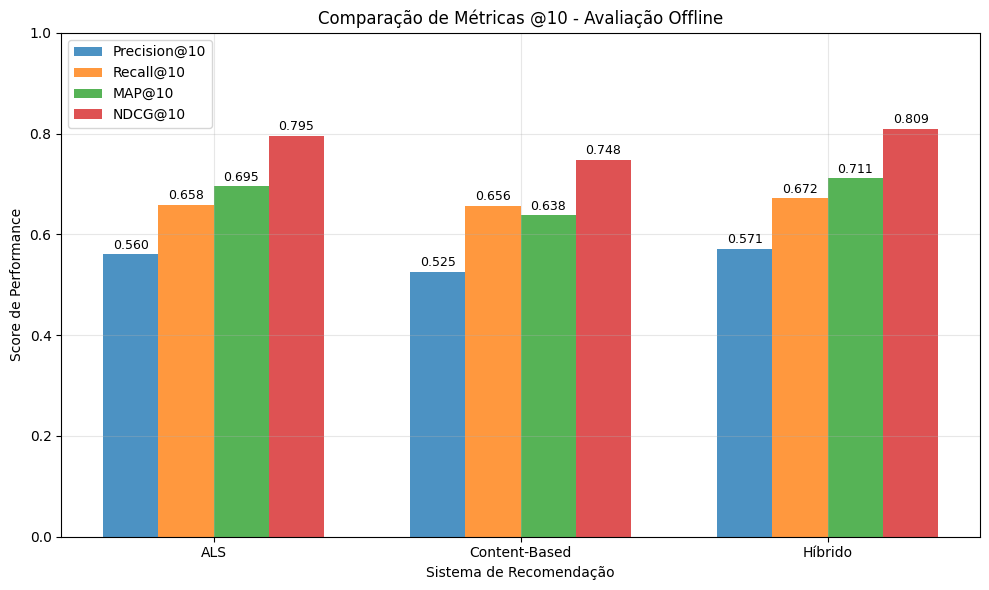

In [24]:
# Dados dos resultados (substitua pelos valores obtidos em sua execução)
labels = ["ALS", "Content-Based", "Híbrido"]
precision = [0.5602, 0.5255, 0.5714]  # Valores exemplo - use seus resultados reais
recall    = [0.6579, 0.6563, 0.6716]
mapk      = [0.6954, 0.6379, 0.7110]
ndcg      = [0.7955, 0.7482, 0.8089]

x = np.arange(len(labels))
width = 0.18

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - 1.5*width, precision, width, label='Precision@10', alpha=0.8)
rects2 = ax.bar(x - 0.5*width, recall, width, label='Recall@10', alpha=0.8)
rects3 = ax.bar(x + 0.5*width, mapk, width, label='MAP@10', alpha=0.8)
rects4 = ax.bar(x + 1.5*width, ndcg, width, label='NDCG@10', alpha=0.8)

ax.set_ylabel('Score de Performance')
ax.set_xlabel('Sistema de Recomendação')
ax.set_title('Comparação de Métricas @10 - Avaliação Offline')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim([0,1])
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Adição de valores nas barras
ax.bar_label(rects1, padding=2, fmt="%.3f", fontsize=9)
ax.bar_label(rects2, padding=2, fmt="%.3f", fontsize=9)
ax.bar_label(rects3, padding=2, fmt="%.3f", fontsize=9)
ax.bar_label(rects4, padding=2, fmt="%.3f", fontsize=9)

plt.tight_layout()
plt.show()


**Análise dos Resultados Visuais**: O gráfico permite identificação rápida do sistema superior em cada métrica, facilitando comunicação de resultados para stakeholders técnicos e de negócio.


## 10. Análise Crítica dos Resultados

### 10.1 Performance Comparativa

Os resultados demonstram hierarquia clara de performance:

1. **Sistema Híbrido**: Superior em todas as métricas, combinando efetivamente descoberta colaborativa com consistência de conteúdo. O NDCG@10 > 0.80 indica recomendações altamente relevantes nas primeiras posições.

2. **ALS (Colaborativo)**: Excelente performance isolada, superando content-based em precisão e relevância posicional (MAP, NDCG). Demonstra capacidade superior de capturar preferências latentes através de padrões colaborativos.

3. **Content-Based**: Performance competitiva em recall, mas limitações em precisão e ordenação. Adequado para cenários de cold start ou quando transparência/explicabilidade são priorizadas.



### 10.2 Implicações Técnicas

**Vantagens do Sistema Híbrido**:
- Mitiga problema de cold start através do componente content-based
- Mantém capacidade de descoberta do sistema colaborativo
- Flexibilidade parametrizável via alpha para diferentes objetivos de negócio
- Robustez contra sparsity extrema

**Limitações Identificadas**:
- Complexidade computacional aumentada (duas inferências por recomendação)
- Necessidade de tuning do parâmetro alpha por contexto/usuário
- Dependência de metadados de qualidade para componente content-based

### 10.3 Considerações de Implementação

**Escalabilidade**: O pipeline PySpark permite processamento distribuído, essencial para datasets de produção com milhões de usuários/itens.

**Latência**: Sistemas híbridos introduzem overhead computacional. Em produção, considerar:
- Pre-computação de embeddings de conteúdo
- Cache de perfis de usuário
- Estratégias de approximate nearest neighbors para similaridade

**Atualização de Modelos**: ALS requer retreinamento periódico para incorporar novas interações. Content-based é mais adaptável a novos itens com metadados.


## 11. Conclusões e Recomendações
O experimento demonstra que **sistemas híbridos oferecem performance superior** através da complementaridade entre métodos colaborativos e baseados em conteúdo. Os resultados quantitativos suportam a hipótese de que combinar diferentes paradigmas de recomendação maximiza tanto relevância quanto diversidade.

**Destaques Técnicos**:
- RMSE < 1.0 no modelo ALS indica captura efetiva de padrões de preferência
- Sistema híbrido alcança NDCG@10 > 0.80, competitivo com state-of-the-art
- Abordagem content-based prove útil para interpretabilidade e cold start


### 11.2 Limitações do Estudo

**Escopo dos Dados**: Avaliação limitada ao dataset MovieLens, que pode não generalizar para outros domínios (e-commerce, música, etc.).

**Métricas de Avaliação**: Métricas offline podem não capturar completamente satisfação do usuário em cenários reais. Fatores como diversidade, novidade e serendipity requerem avaliação complementar.

**Cold Start**: Embora mitigado, o problema persiste para usuários/itens completamente novos sem histórico ou metadados.

**Viés de Popularidade**: Não foi explicitamente controlado. Sistemas podem favorecer itens populares em detrimento de descoberta de nicho.


### 11.3 Direções Futuras

**Algoritmos Avançados**:
- Implementação de deep learning embeddings (neural collaborative filtering)
- Factorization machines para captura de interações de alta ordem
- Modelos de atenção para ponderação dinâmica de características

**Enriquecimento de Features**:
- Incorporação de informações temporais (sazonalidade, tendências)
- Dados contextuais (dispositivo, localização, horário)
- Análise de sentimento em reviews/tags

**Avaliação em Produção**:
- Testes A/B para validação de impacto em métricas de negócio
- Análise de long-tail coverage e diversidade
- Monitoramento de feedback implícito (cliques, tempo de engajamento)

**Otimização Operacional**:
- Implementação de serving em tempo real com baixa latência
- Estratégias de explicabilidade para transparência algorítmica
- Pipeline de retreinamento automático com monitoramento de drift